# Authors

- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [1]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

import os

2025-03-10 21:50:16.552827: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 21:50:16.613447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741639816.633659  217952 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741639816.643643  217952 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-10 21:50:16.670610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Functions

In [2]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Preprocessing

#### LOADING DATA

In [3]:
!pip install opencv-python

In [4]:
import os
import cv2
import numpy as np

# Ruta al dataset
dataset_path = 'dataset'

# Listas para las imágenes y etiquetas
X = []
y = []

# Tamaño al que redimensionar las imágenes (puedes cambiarlo)
img_size = (224, 224)  # ancho x alto

# Recorrer las carpetas
for label in os.listdir(dataset_path):
    print(f"Procesando {label}")

    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):  # Asegurarse de que es una carpeta
        for file_name in os.listdir(label_path):
            file_path = os.path.join(label_path, file_name)
            # Leer la imagen con cv2
            img = cv2.imread(file_path)
            if img is not None:  # Verificar que la imagen se leyó correctamente
                # Convertir de BGR a RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Redimensionar la imagen
                img = cv2.resize(img, img_size)
                # Añadir a las listas
                X.append(img)
                y.append(label)
            else:
                print(f"Error al leer la imagen: {file_path}")
        

# Convertir a arrays de numpy
X = np.array(X)
y = np.array(y)

print(f"Total de imágenes cargadas: {len(X)}")
print(f"Etiquetas únicas: {set(y)}")

Procesando Acitinic Keratosis
Procesando Basal Cell Carcinoma
Procesando Dermatofibroma
Error al leer la imagen: dataset/Dermatofibroma/metadata.csv
Procesando Melanoma
Total de imágenes cargadas: 1904
Etiquetas únicas: {np.str_('Melanoma'), np.str_('Basal Cell Carcinoma'), np.str_('Acitinic Keratosis'), np.str_('Dermatofibroma')}


In [5]:
from keras.utils import to_categorical

In [6]:
y = pd.get_dummies(y)

#### TRAINING AND TEST SETS

In [7]:
!pip install scikit-learn

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
len(X_train), len(X_test), len(y_train), len(y_test)

(1275, 629, 1275, 629)

## Models

### Model 1

#### Creation

We define an augmentation layer that will increase artificially the number of input images, to avoid overfitting, with a random rotation and zoom

In [11]:
data_augmentation_layer_1 = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.2),
    ]
)

I0000 00:00:1741639899.083195  217952 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:98:00.0, compute capability: 7.5


Then we define the architecture of the first model, with a rescaling layer to put all the pixel values in the range [0,1], several convolutional layers, a pooling layer and the a flatten layer. Finally, we apply dropout in order to avoid overfitting. The ouput layer is a Dense layer with 20 units, because we have 20 output classes.

In [12]:
inputs = keras.Input(shape=(224, 224, 3, ))

x = data_augmentation_layer_1(inputs)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(4, activation="softmax")(x)
model_1 = keras.Model(inputs = inputs, outputs = outputs)
model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        51,204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,620 (1.68 MB)

 Trainable params: 439,620 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

#### Compilation

We use the adam optimizer because of its adaptation to the situation

In [13]:
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics = ["accuracy"]
)

#### Tranining

We define an early stopping callback so we can end the training when the "val_loss" has not been increased in 15 epochs

In [14]:
early_stopping_cb = EarlyStopping(patience=15, monitor="val_accuracy", mode="max", restore_best_weights=True)

We define a validation set of 20% of the total data

In [15]:
history_model_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping_cb]
)

Epoch 1/200


I0000 00:00:1741639907.087719  246287 cuda_dnn.cc:529] Loaded cuDNN version 90300


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.2596 - loss: 1.3852 - val_accuracy: 0.4039 - val_loss: 1.3314
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.4023 - loss: 1.3314 - val_accuracy: 0.3255 - val_loss: 1.3510
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.3519 - loss: 1.3318 - val_accuracy: 0.4549 - val_loss: 1.1850
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4666 - loss: 1.1766 - val_accuracy: 0.4941 - val_loss: 1.1305
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.4737 - loss: 1.1498 - val_accuracy: 0.4353 - val_loss: 1.1818
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.4730 - loss: 1.1779 - val_accuracy: 0.4980 - val_loss: 1.1238
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4698 - loss: 1.1235 - val_accuracy: 0.5255 - val_loss: 1.0593
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4844 - loss: 1.0732 - val_accuracy: 0.50

In [16]:
model_1.save("Model1.h5")

<Axes: >

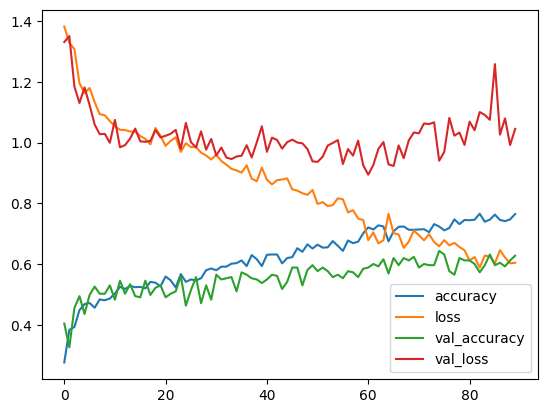

In [17]:
pd.DataFrame(history_model_1.history).to_csv("Model1_Train_History.csv")
pd.DataFrame(history_model_1.history).plot()

#### Testing

Finally, we test the model with data that it has never seen

In [18]:
model_1.evaluate(X_test, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5992 - loss: 0.9433


[0.9688341021537781, 0.6152623295783997]

---